In [1]:
# Celda 1: Instalación, Importaciones y Carga de Datos
!pip install ucimlrepo pandas numpy matplotlib seaborn

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A. Carga de Datos (Usando ucimlrepo)
print("Cargando dataset de Eficiencia Energética (id=242)...")
energy_efficiency = fetch_ucirepo(id=242)

Cargando dataset de Eficiencia Energética (id=242)...


In [2]:
# Celda 2: Separación, Renombrado y Discretización (Target Multiclase)

# B. Separación automática de Features (X) y Targets (y)
X = energy_efficiency.data.features
y = energy_efficiency.data.targets

# --- Renombrado de Features (X1 a X8) para legibilidad ---
X.columns = ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
             'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
print("Features renombradas:", X.columns.tolist())

# Renombrar columnas 'y' (Corregida la 's' de 'columns')
y = y.rename(columns={'Y1': 'Carga_calefaccion', 'Y2': 'Carga_Refrigeracion'})
print('Variables objetivo (y):', y.columns.tolist())

# --- PASO CLAVE: DISCRETIZACIÓN MULTICLASE ---

# C. Discretización: ¡USAMOS CORCHETES [] para mantener el orden!
etiquetas = ['Baja', 'Media', 'Alta', 'Critica'] # <-- CORRECCIÓN CLAVE
y['Demanda_Clase'] = pd.qcut(
    y['Carga_calefaccion'],
    q=len(etiquetas),
    labels=etiquetas
)

# Opcional: Juntar X e Y para un EDA más completo de una vez
df_completo = pd.concat([X, y], axis=1)


Features renombradas: ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
Variables objetivo (y): ['Carga_calefaccion', 'Carga_Refrigeracion']


In [3]:
# Celda 3: Verificación del Target Multiclase
print("\n--- Verificación del Target Multiclase ---")
print("Distribución de Clases:")
print(y['Demanda_Clase'].value_counts())
print("\nProporciones:")
print(y['Demanda_Clase'].value_counts(normalize=True) * 100)



--- Verificación del Target Multiclase ---
Distribución de Clases:
Demanda_Clase
Baja       192
Media      192
Alta       192
Critica    192
Name: count, dtype: int64

Proporciones:
Demanda_Clase
Baja       25.0
Media      25.0
Alta       25.0
Critica    25.0
Name: proportion, dtype: float64


--- Resumen Estadístico de Features Numéricas ---
       Compactness  Surface_Area   Wall_Area   Roof_Area  Overall_Height  \
count   768.000000    768.000000  768.000000  768.000000       768.00000   
mean      0.764167    671.708333  318.500000  176.604167         5.25000   
std       0.105777     88.086116   43.626481   45.165950         1.75114   
min       0.620000    514.500000  245.000000  110.250000         3.50000   
25%       0.682500    606.375000  294.000000  140.875000         3.50000   
50%       0.750000    673.750000  318.500000  183.750000         5.25000   
75%       0.830000    741.125000  343.000000  220.500000         7.00000   
max       0.980000    808.500000  416.500000  220.500000         7.00000   

       Orientation  Glazing_Area  Glazing_Area_Distribution  
count   768.000000    768.000000                  768.00000  
mean      3.500000      0.234375                    2.81250  
std       1.118763      0.133221                    1.55096  
min       2.00000

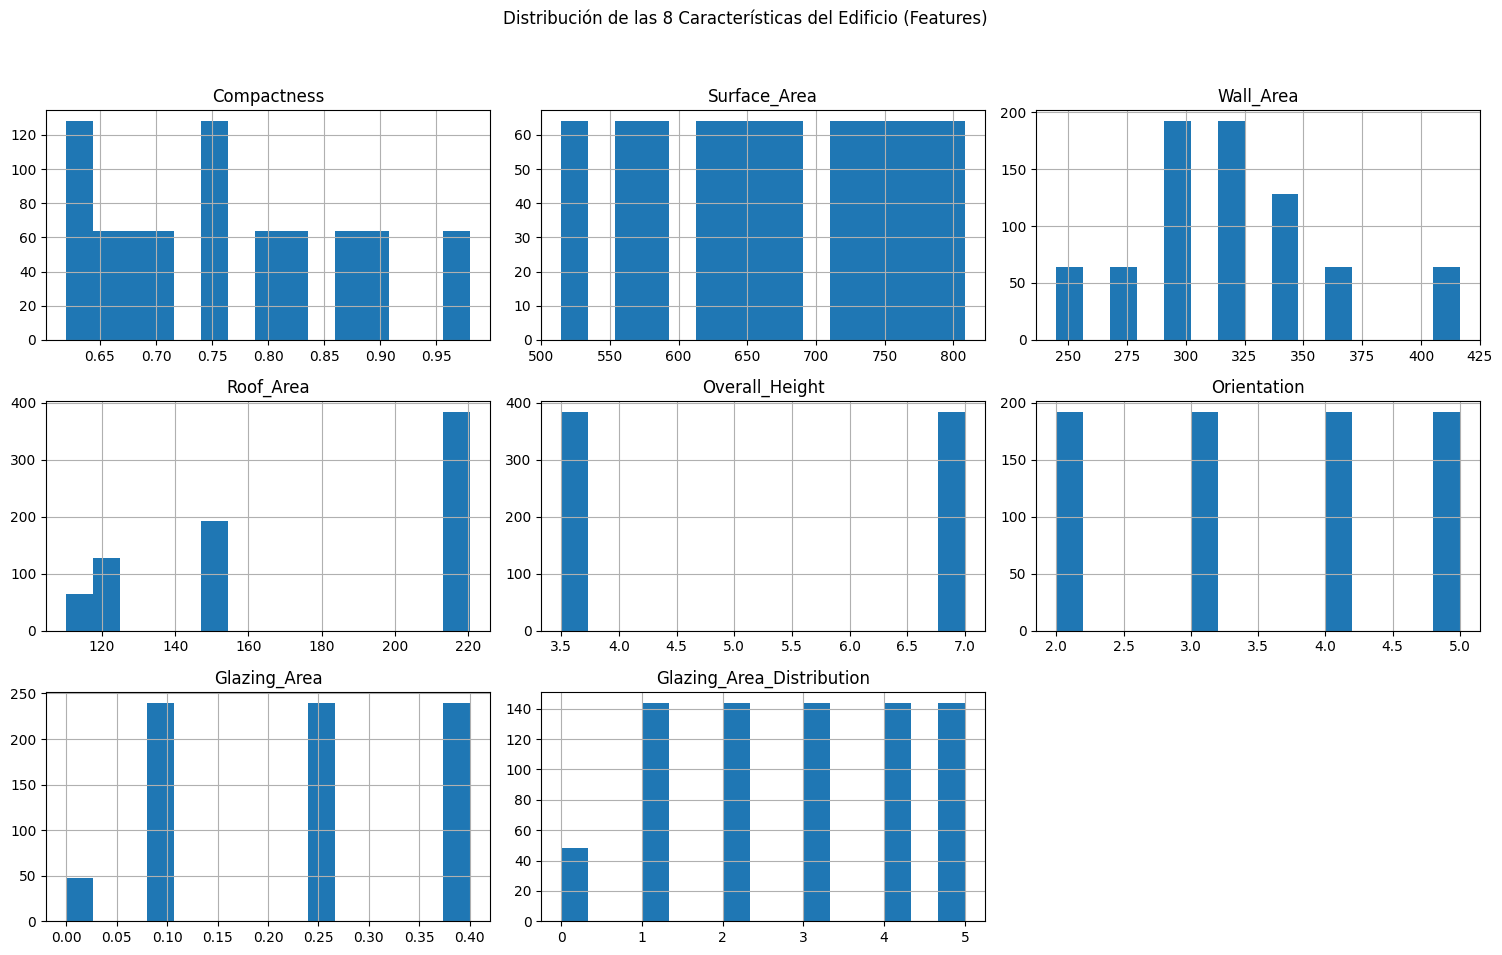

In [4]:
# Celda 4: EDA Univariado (Análisis de Distribución y Escala)

print("--- Resumen Estadístico de Features Numéricas ---")
# Esto ayuda a ver la dispersión y si las escalas son muy diferentes (necesidad de Scaler)
print(X.describe())

# Visualización de la distribución de las 8 features
# Usamos el DataFrame 'X' renombrado, pero el df_completo también funcionaría
X.hist(figsize=(15, 10), bins=15)
plt.suptitle('Distribución de las 8 Características del Edificio (Features)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el título
plt.savefig('../resources/img/eda_distribucion_univariada.png')
plt.show()

# Observación: Las variables X6 (Orientation) y X8 (Glazing_Area_Distribution) son categóricas (o discretas)
# y su distribución se ve mejor con un countplot o tabla.

1. Análisis Univariado: Escala y Tipo de Dato

>
    Observaciones Clave:
    A) Dispersión y Escala (Tabla .describe()): Existe una gran disparidad en las escalas de las features. Por ejemplo, Overall_Height solo varía entre 3.5 y 7.0, mientras que Surface_Area varía entre 514.5 y 808.5.
    
    B) Tipos de Datos (Histogramas): Variables como Overall_Height (solo dos valores), Orientation y Glazing_Area_Distribution son claramente discretas o categóricas, a pesar de estar representadas como números.


Esta evidencia justifica la necesidad OBLIGATORIA de realizar dos pasos en el preprocesamiento:

1. Aplicar un Scaler (StandardScaler o MinMaxScaler) a todas las features numéricas.

2. Aplicar One-Hot Encoding a las features discretas/categóricas (Orientation, Glazing_Area_Distribution, Overall_Height) para que el modelo las interprete correctamente.

/tmp/ipython-input-3456632518.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Demanda_Clase', y=feature, data=df_completo, order=orden_clases, palette='Set2')
/tmp/ipython-input-3456632518.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Demanda_Clase', y=feature, data=df_completo, order=orden_clases, palette='Set2')
/tmp/ipython-input-3456632518.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Demanda_Clase', y=feature, data=df_completo, order=orden_clases, palette='Set2')
/tmp/ipython-input-3456632518.py:12: FutureWar

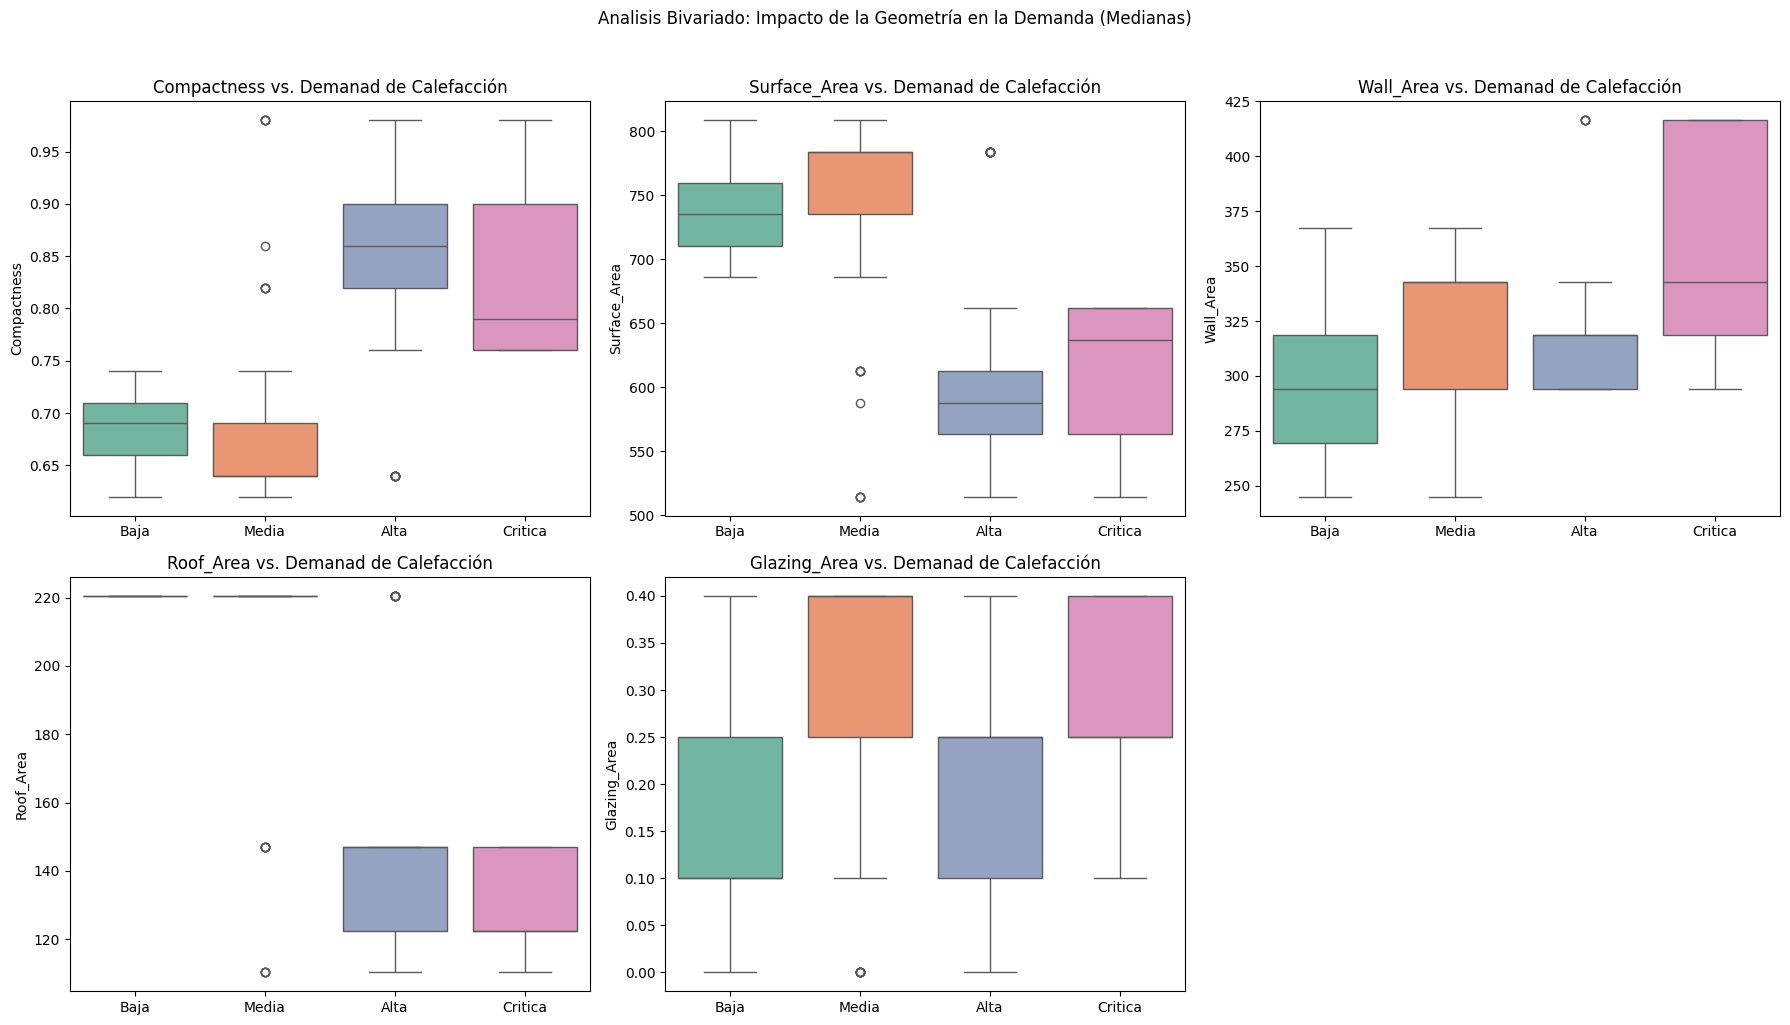

In [7]:
# Celda 5: EDA Bivariado - Relación Feature Continua vs. Target Multiclase

# Tareas: Usaremos Boxplots en las 5 features continuas principales (X1 a X5, y X7)
features_continuas = ['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Glazing_Area']
orden_clases =  ['Baja', 'Media', 'Alta', 'Critica']

plt.figure(figsize=(18, 10))

for i, feature in enumerate(features_continuas):
    plt.subplot(2,3,i+1)
    #Boxplot compara la mediana y la dispersión de la feature 'y' para cada clase 'x'
    sns.boxplot(x='Demanda_Clase', y=feature, data=df_completo, order=orden_clases, palette='Set2')
    plt.title(f'{feature} vs. Demanad de Calefacción')
    plt.xlabel('')

plt.suptitle('Analisis Bivariado: Impacto de la Geometría en la Demanda (Medianas)', y=1.02)
plt.tight_layout()
plt.savefig('../resources/img/eda_impacto_geometrico_boxplots.png')
plt.show()

# Observación: Busca boxplots donde las cajas NO se solapen mucho entre las clases Baja y Crítica.
# Esas features serán tus "predictores estrella".

2. Análisis Bivariado: Impacto del Diseño en la Demanda

>
    Objetivo: Identificar qué features tienen la mayor separación entre los rangos de la clase Baja y Crítica.
    
    Hallazgos Clave:
    A) Compactness (Compacidad): Se observa una relación positiva fuerte. Los edificios con una compacidad más alta tienden a caer consistentemente en las clases Alta y Crítica de demanda.

    B) Roof_Area y Surface_Area: Muestran patrones inversos. La Surface_Area tiende a ser más baja para la Demanda Crítica.

Conclusiones del analisis bivariado:

El diseño arquitectónico (especialmente la compacidad del edificio) es el factor determinante principal de la demanda energética.

El diseño compacto y alto parece ser un riesgo significativo.

Compactness es uno de nuestros predictores clave.

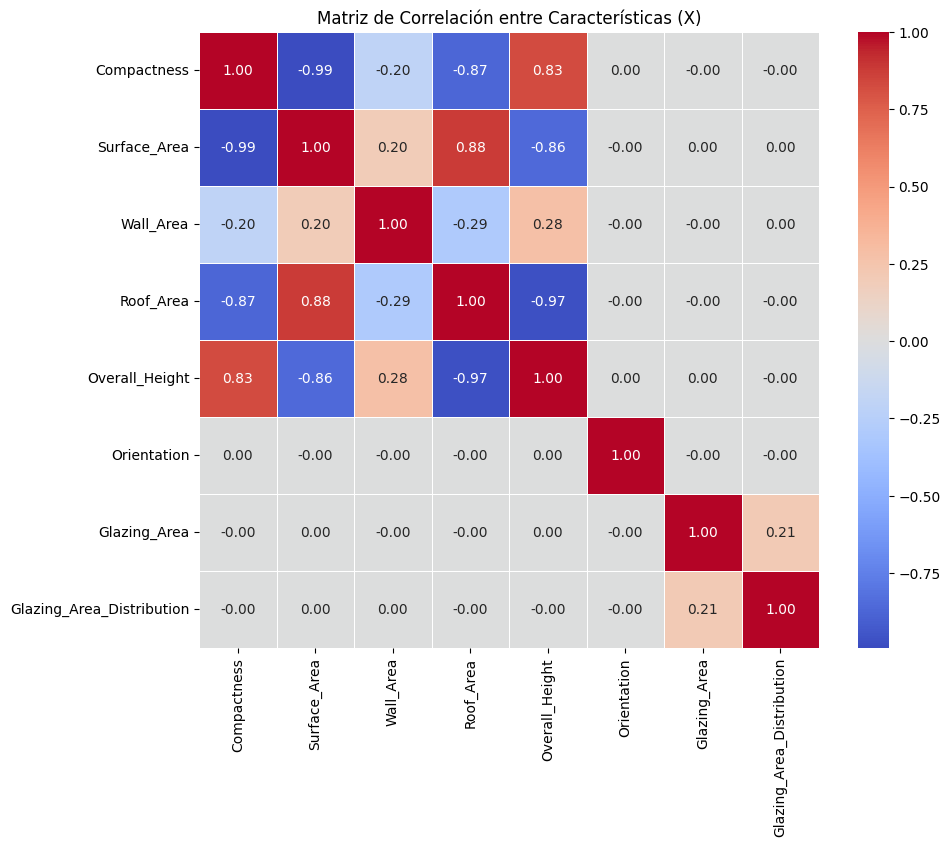

In [9]:
# Celda 6: Matriz de Correlación (Análisis de Multicolinealidad)

# Calcular la matriz de correlación solo para las features 'X'
matriz_corr = X.corr()

plt.figure(figsize=(10, 8))
# Heatmap es la forma visual de ver la correlación
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación entre Características (X)')
plt.savefig('../resources/img/eda_correlacion_heatmap.png')
plt.show()

3. Análisis de Correlación: Identificación de Redundancia


>
    Objetivo: Buscar correlaciones cercanas a $\pm 1.00$ para evitar introducir información redundante (multicolinealidad) en el modelo.
    
    Hallazgos Clave (Redundancia Crítica):
    Compactness y Surface_Area: La correlación es de -0.99. Esto indica que ambas features miden virtualmente el mismo concepto físico.
    
Conclusión para el Pipeline (Feature Selection): Para simplificar el modelo y garantizar su estabilidad, se eliminará Surface_Area del pipeline. La Compactness se mantendrá como feature principal por su fuerte impacto en la demanda (visto en el EDA Bivariado).



In [13]:
# Celda 7: Definición y Construcción del Pipeline de Preprocesamiento

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# 1. Definición de las Features
# Basado en el EDA, eliminamos 'Surface_Area' por multicolinealidad con 'Compactness'.
numericas_cont = ['Compactness', 'Glazing_Area', 'Wall_Area', 'Roof_Area']
categoricas_disc = ['Overall_Height', 'Orientation', 'Glazing_Area_Distribution']

# 2. Creación del Preprocesador para Numéricas
# Usamos StandardScaler porque la distribución de las features es variable (no Gaussiana pura)
# y las escalas son muy diferentes.
transformador_numerico = StandardScaler()

# 3. Creación del Preprocesador para Categóricas
# Usamos OneHotEncoder para convertir valores discretos (2, 3, 4, 5) en columnas binarias.
transformador_categorico = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


# 4. Creación del ColumnTransformer (La Receta)
# Aplica el StandardScaler a las numéricas y el OneHotEncoder a las categóricas.
preprocesador = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, numericas_cont),
        ('cat', transformador_categorico, categoricas_disc)
    ],
    remainder='drop', # Esto elimina CUALQUIER columna de X que NO esté en 'num' o 'cat', incluyendo 'Surface_Area'.
    verbose_feature_names_out=False # Para que los nombres de las columnas sean mas limpios.

)

print("Pipeline de Preprocesamiento (ColumnTransformer) definido con éxito.")

Pipeline de Preprocesamiento (ColumnTransformer) definido con éxito.


Conclusión del EDA y Diseño del Pipeline


>
    Decisiones Basadas en el Análisis:
    1. Feature Selection: La feature Surface_Area ha sido eliminada del pipeline debido a su altísima correlación ($-0.99$) con Compactness (visto en el Heatmap).
    Mantener ambas introduciría redundancia (multicolinealidad), por lo que se prioriza la simplicidad y estabilidad del modelo.

    2. Tratamiento de Datos Numéricos: Se aplica StandardScaler a las features con alta dispersión (Compactness, Glazing_Area, etc.).
    Esto es crucial para llevar todas las variables a una escala similar, impidiendo que la Surface_Area (con valores grandes) domine sobre la Overall_Height (con valores pequeños).
    
    3. Tratamiento de Datos Categóricos/Discretos: Se aplica OneHotEncoder a las features con pocos valores únicos (Overall_Height, Orientation, Glazing_Area_Distribution).
    Esto transforma estos números en variables binarias (0 o 1), permitiendo que el modelo las interprete como categorías y no como valores continuos.

In [14]:
# Celda 8: Aplicación y Verificación del Preprocesador

# 1. Aplicamos el preprocesador al DataFrame de Features (X)
X_procesado = preprocesador.fit_transform(X)

print("X original (primeras 5 filas):\n", X.head())

print("\n-----------------------------------------------------------")

print("X procesado (primeras 5 filas después de transformación):")
# Convertimos el resultado de NumPy a DataFrame para mejor visualización
# NOTA: Los nombres de las columnas serán los originales más los nuevos del OneHotEncoder
X_df_procesado = pd.DataFrame(X_procesado, columns=preprocesador.get_feature_names_out())

# 2. Mostramos el resultado. Deberías ver:
#   - Las features numéricas escaladas (valores cercanos a 0)
#   - Las features categóricas convertidas en muchas columnas binarias (0s y 1s)
print(X_df_procesado.head())

X original (primeras 5 filas):
    Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0         0.98         514.5      294.0     110.25             7.0   
1         0.98         514.5      294.0     110.25             7.0   
2         0.98         514.5      294.0     110.25             7.0   
3         0.98         514.5      294.0     110.25             7.0   
4         0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  
0            2           0.0                          0  
1            3           0.0                          0  
2            4           0.0                          0  
3            5           0.0                          0  
4            2           0.0                          0  

-----------------------------------------------------------
X procesado (primeras 5 filas después de transformación):
   Compactness  Glazing_Area  Wall_Area  Roof_Area  Overall_Height_3.5  \
0     

Verificación Final del Pipeline
>
    La aplicación del ColumnTransformer (Celda 8) fue exitosa y verificó las conclusiones del EDA:

    1. Limpieza de Datos: Las features numéricas ahora están estandarizadas (valores centrados en $0.0$)
    y las features discretas están correctamente codificadas (transformadas en columnas binarias $0$ o $1$).
    Esto prepara los datos para cualquier algoritmo de Machine Learning.
    
    2. Validación de la Eliminación: El ajuste remainder='drop' confirmó que la feature redundante Surface_Area ha sido eliminada del dataset final,
    cumpliendo con nuestra justificación de Feature Selection (Celda 6).

El DataFrame X_procesado está ahora limpio, estandarizado y optimizado, listo para ser dividido y utilizado en la fase de entrenamiento de modelos.

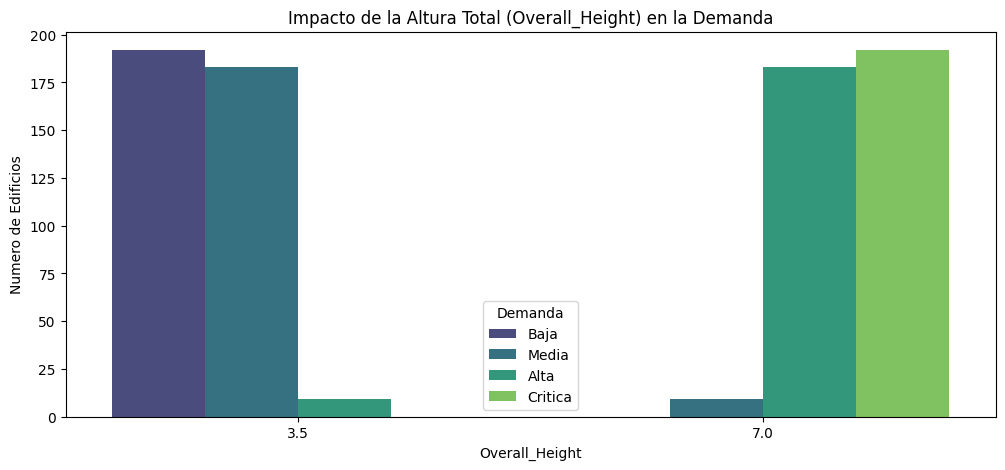

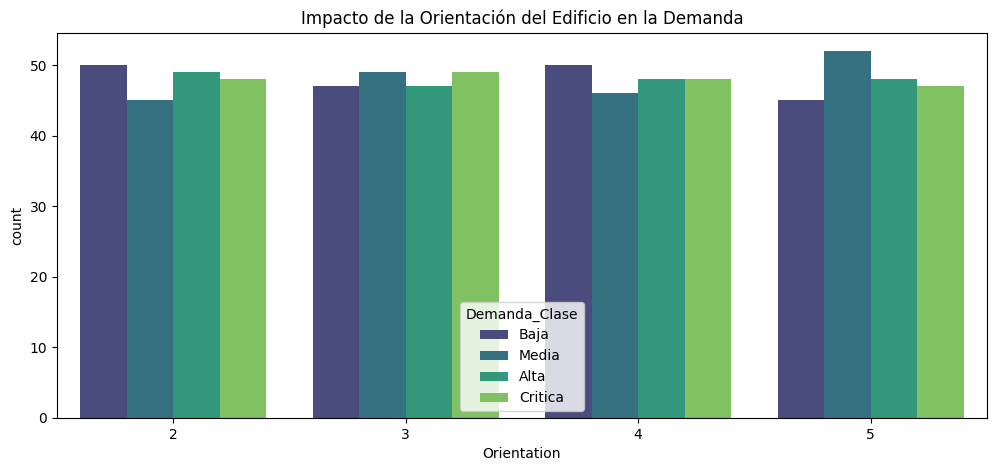

In [15]:
# Celda 10: Análisis Bivariado - Impacto de Features Categóricas (Nivel Destacado)

# 1. Analizar el impacto de la Altura Total (Overall_Height)
plt.figure(figsize=(12, 5))

# El countplot con 'hue' es ideal para ver cómo se distribuye el target en las categorías
sns.countplot(x='Overall_Height', hue='Demanda_Clase', data=df_completo, palette='viridis',
              order=sorted(df_completo['Overall_Height'].unique()))
plt.title('Impacto de la Altura Total (Overall_Height) en la Demanda')
plt.ylabel('Numero de Edificios')
plt.legend(title='Demanda')
plt.savefig('../resources/img/eda_altura_impacto.png')
plt.show()

# 2. Analizar el impacto de la Orientación
plt.figure(figsize=(12, 5))
sns.countplot(x='Orientation', hue='Demanda_Clase', data=df_completo, palette='viridis')
plt.title('Impacto de la Orientación del Edificio en la Demanda')
plt.savefig('../resources/img/eda_orientacion_impacto.png')
plt.show()

Riesgo energético: La Altura como Factor Primordial (Hallazgo Destacado)


>
    El análisis de las features categóricas/discretas (Overall_Height y Orientation)
    reveló el factor de diseño más crítico para el riesgo energético:

    1. Factor de Riesgo Máximo (Altura): La Altura Total (Overall_Height)
    es el impulsor de riesgo más claro y fuerte.

      Diseño de Bajo Riesgo: Los edificios de 3.5 metros se asocian casi
      exclusivamente con las categorías de demanda Baja y Media.
      Diseño de Alto Riesgo: Los edificios de 7.0 metros concentran
      casi todas las instancias de demanda Alta y Crítica.
      Implicación: Esta feature es, por sí sola,
      una de las más determinantes para la clasificación.

    2. Factor Inactivo (Orientación): El análisis de la Orientación del edificio (si mira al Norte, Sur, Este u Oeste)
    mostró que la distribución de las clases de demanda (Baja a Crítica) es prácticamente
    uniforme para todas las orientaciones.

      Implicación: Esto sugiere que esta feature no tiene un poder predictivo significativo en el modelo.
      Aunque se incluye inicialmente en el pipeline, se recomienda considerar su eliminación
      en una optimización posterior para simplificar el modelo sin perder rendimiento.

Conclusión General del EDA: La geometría del edificio, particularmente la Altura y la Compacidad (visto en los Boxplots), tiene un impacto directo y predecible en la demanda energética, mientras que factores externos como la Orientación son irrelevantes en este dataset.